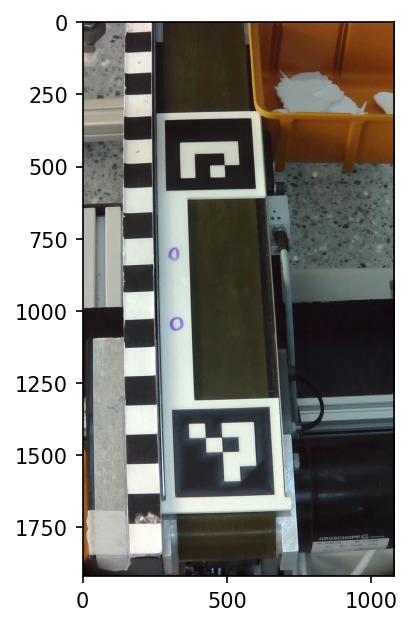

In [102]:
import cv2 as cv
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from cv2 import aruco
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('aruco_pic/foto_0.png')
img_aruco_rotated = cv.rotate(img_aruco,2)

# Test Bild
img_obj = cv.imread('obj/cat/foto_10.png')
img_obj_rotated = cv.rotate(img_obj,2)

SRC_COORDS = (np.array([[[ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                                [ 0., 222.], [60., 222.], [60., 282.], [ 0., 282.]]], dtype= np.float32))

plt.imshow(img_aruco_rotated)

# Bildauschnitt errechnen und segmentierung einstellen

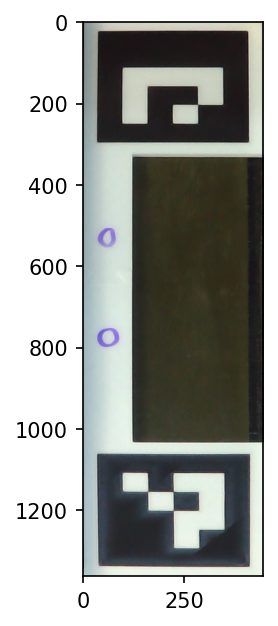

In [103]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)

dstPoints = np.concatenate(corners, axis=1)
H, _ = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)

pts1 = np.float32([
    corners[1][0][0],  # oben-links
    corners[1][0][1],  # oben-rechts
    corners[0][0][3],  # unten-links
    corners[0][0][2],  # unten-rechts
])

pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)

# Pixel in Bild zu welt
world_frame = cv.perspectiveTransform(pts1_reshaped, H_inv)

# versatz - mit X und Y Offsets
offset_raw = np.array([
    [-6, +6],  # mm - X offset -6, Y offset -6
    [+6, +6],  # mm - X offset +6, Y offset -6
    [-6, -6],  # mm - X offset -6, Y offset +6
    [+6, -6]   # mm - X offset +6, Y offset +6
], dtype=np.float32)

offset = offset_raw.reshape(-1, 1, 2)
pts1_2 = world_frame + offset

pts1_2_pixel = cv.perspectiveTransform(pts1_2, H)

min_x = np.min(pts1_2_pixel[:, 0, 0])
max_x = np.max(pts1_2_pixel[:, 0, 0])
min_y = np.min(pts1_2_pixel[:, 0, 1])
max_y = np.max(pts1_2_pixel[:, 0, 1])

width = int(max_x - min_x)
height = int(max_y - min_y)

pts2_proportional = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])
M_for_all = cv.getPerspectiveTransform(pts1_2_pixel, pts2_proportional)

img_warped = cv.warpPerspective(img_aruco_rotated, M_for_all, (width, height))
plt.imshow(img_warped)

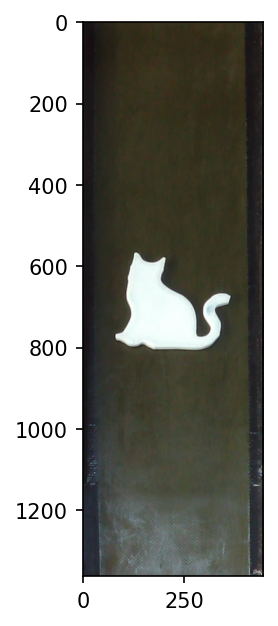

In [104]:
dst_obj = cv.warpPerspective(img_obj_rotated, M_for_all, (width, height))
plt.imshow(dst_obj)

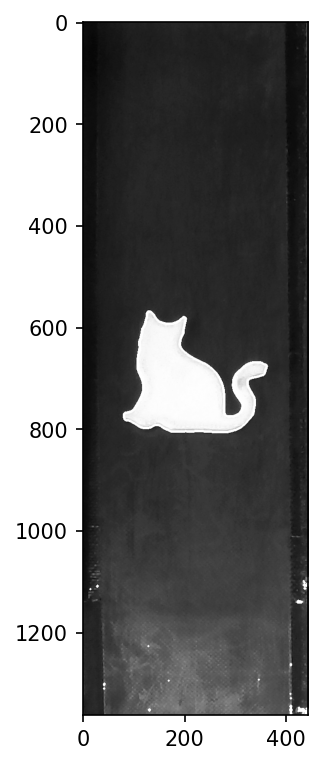

In [105]:
gray_image = cv.cvtColor(dst_obj, cv.COLOR_BGR2GRAY)

ret , img_thresh = cv.threshold(gray_image, 150, 255,cv.THRESH_BINARY + cv.THRESH_OTSU)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = gray_image.copy()

cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')

In [106]:
cwd = Path.cwd()

# Prefer local notebook directory if the notebook is already running from misc/prepWork/dev_pictures.
# Otherwise resolve from the repository root.
candidate_paths = [
    cwd / "obj",
    cwd / "misc" / "prepWork" / "dev_pictures" / "obj",
    cwd / "dev_pictures" / "obj",
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        f"DATA_PATH not found. Checked: {candidate_paths} (cwd={cwd})"
    )

print("Using DATA_PATH:", DATA_PATH)



Using DATA_PATH: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_pictures/obj


In [107]:
def warp_image(img):

    img_rotated = cv.rotate(img,2)

    dst_obj = cv.warpPerspective(img_rotated, M_for_all, (width, height))
    return dst_obj

def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)

    M = cv.getRotationMatrix2D(center, angle, 1.0)

    return cv.warpAffine(
        img,
        M,
        (w, h),
        flags=cv.INTER_LINEAR,
        borderValue=(255, 255, 255)
    )


def mirror_image(img):
    return cv.flip(img, 1)

In [108]:
def extract_main_contour(img):

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # blur = cv.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv.threshold(gray, 150, 255, cv.THRESH_BINARY)

    uint8_img_thresh = thresh.astype(np.uint8)

    contours, _ = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    return max(contours, key=cv.contourArea)

In [109]:
def extract_features(cnt):

    features = {}

    area = cv.contourArea(cnt)
    perimeter = cv.arcLength(cnt, True)

    if area == 0 or perimeter == 0:
        return None

    features["area"] = area
    features["perimeter"] = perimeter

    # Shape approx
    epsilon = 0.04 * perimeter
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features["corners"] = len(approx)

    # Bounding box
    x, y, w, h = cv.boundingRect(cnt)

    features["aspect_ratio"] = w / h
    features["bbox_w"] = w
    features["bbox_h"] = h

    # Circularity
    features["circularity"] = (4 * np.pi * area) / (perimeter ** 2)

    # Solidity
    hull = cv.convexHull(cnt)
    hull_area = cv.contourArea(hull)

    features["solidity"] = area / hull_area if hull_area > 0 else 0

    # Hu Moments
    hu_raw = cv.HuMoments(cv.moments(cnt)).flatten()

    with np.errstate(divide="ignore"):
        hu_log = -np.sign(hu_raw) * np.log10(np.abs(hu_raw) + 1e-10)

    for i in range(7):
        features[f"hu_{i}"] = float(hu_log[i])  

    # Fourier Descriptors
    contour_pts = cnt[:, 0, :]
    complex_contour = contour_pts[:, 0] + 1j * contour_pts[:, 1]
    fourier = np.fft.fft(complex_contour)

    fourier = np.abs(fourier)
    fourier = fourier[1:]                          # ← fd_0 weglassen (Translation)
    fourier = fourier / (fourier[0] + 1e-10)      # ← durch fd_1 teilen (Skalierung)

    N_DESCRIPTORS = 10
    for i in range(N_DESCRIPTORS):
        features[f"fd_{i+1}"] = float(fourier[i]) if i < len(fourier) else 0

    M_moments = cv.moments(cnt)
    features["symmetry"] = abs(M_moments["mu11"]) / (M_moments["mu20"] + M_moments["mu02"] + 1e-6)

    return features

In [110]:
angles = [0, 15, 30,45, 60,  75,90,105,120,135,150,165,170,185,200,215,230,245,260,275,290,305,320,335,350]

rows = []

In [111]:
from pathlib import Path

DEBUG_PATH = Path("debug_contours")
DEBUG_PATH.mkdir(exist_ok=True)

for class_dir in DATA_PATH.iterdir():
    if not class_dir.is_dir():
        continue

    label = class_dir.name
    print("Processing:", label)
    out_dir = DEBUG_PATH / label
    out_dir.mkdir(exist_ok=True)

    for img_path in class_dir.glob("*.png"):

        img_first = cv.imread(str(img_path))
        img = warp_image(img_first)

        if img is None:
            continue

        # Alle Varianten
        variants = {}
        for angle in angles:
            variants[f"{img_path.stem}_rot{angle}"] = rotate_image(img, angle)

        mirrored = mirror_image(img)
        for angle in angles:
            variants[f"{img_path.stem}_mir{angle}"] = rotate_image(mirrored, angle)

        for name, v in variants.items():

            cnt = extract_main_contour(v)
            if cnt is None:
                continue

            # Debug-Bild speichern
            h, w = v.shape[:2]
            contour_img = np.zeros((h, w), dtype=np.uint8)
            cv.drawContours(contour_img, [cnt], -1, 255, 2)
            x, y, bw, bh = cv.boundingRect(cnt)
            cv.rectangle(contour_img, (x, y), (x+bw, y+bh), 180, 1)
            cv.imwrite(str(out_dir / f"{name}.png"), contour_img)

            # Features extrahieren
            feat = extract_features(cnt)
            if feat is None:
                continue

            feat["label"] = label
            rows.append(feat)

print("✅ Kontur-Bilder gespeichert unter:", DEBUG_PATH.resolve())

Processing: unicorn
Processing: cat
Processing: rejected
✅ Kontur-Bilder gespeichert unter: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_pictures/debug_contours


In [112]:
df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)

df.to_csv("features_dataset.csv", index=False)

df.head()

Dataset shape: (28600, 27)


,area,perimeter,corners,aspect_ratio,bbox_w,bbox_h,circularity,solidity,hu_0,hu_1,...,fd_3,fd_4,fd_5,fd_6,fd_7,fd_8,fd_9,fd_10,symmetry,label
0,37416.0,1084.832601,7,0.932836,250,268,0.399523,0.768414,0.741609,4.545854,...,1.250666,2.365656,1.118760,0.058854,0.055709,0.042578,0.204730,0.459759,0.011971,unicorn
1,56318.0,1544.073156,3,0.269231,175,650,0.296839,0.994113,0.352649,0.795693,...,0.330605,0.246673,0.196149,0.163196,0.139111,0.121089,0.107225,0.096015,0.125133,unicorn
2,110985.0,1746.288447,3,0.578100,359,621,0.457343,0.996937,0.590893,1.541216,...,0.329956,0.246000,0.196040,0.162309,0.138357,0.120385,0.106562,0.095298,0.216593,unicorn
3,162362.0,1803.082410,4,0.753820,444,589,0.627571,0.998647,0.688882,2.065680,...,0.679987,1.950222,2.952639,5.213877,5.364735,0.000000,0.000000,0.000000,0.216070,unicorn
4,216585.5,2665.692555,6,0.555695,444,799,0.383018,0.816333,0.607082,1.713954,...,0.257310,0.070097,0.083192,0.057959,0.076894,0.038745,0.035817,0.046069,0.195744,unicorn


         feature     f_score        p_value
2        corners  535.854076  3.437665e-229
7       solidity  518.890515  4.379114e-222
1      perimeter  331.210371  6.278592e-143
16          fd_2  169.923936   4.345425e-74
18          fd_4  166.196848   1.729346e-72
15          fd_1  145.903061   9.040935e-64
22          fd_8  108.402013   1.256510e-47
6    circularity  107.553526   2.916739e-47
24         fd_10  106.323761   9.885821e-47
19          fd_5  103.475822   1.670510e-45
23          fd_9   99.814352   6.335505e-44
20          fd_6   87.259581   1.655055e-38
4         bbox_w   65.870371   2.874441e-29
21          fd_7   63.192881   4.131885e-28
3   aspect_ratio   30.808097   4.311289e-14
11          hu_3   28.387616   4.826553e-13
10          hu_2   27.398409   1.295412e-12
0           area   17.402432   2.797790e-08
25      symmetry   15.105746   2.774091e-07
8           hu_0   12.454856   3.919937e-06
5         bbox_h    6.398292   1.666781e-03
13          hu_5    5.545607   3

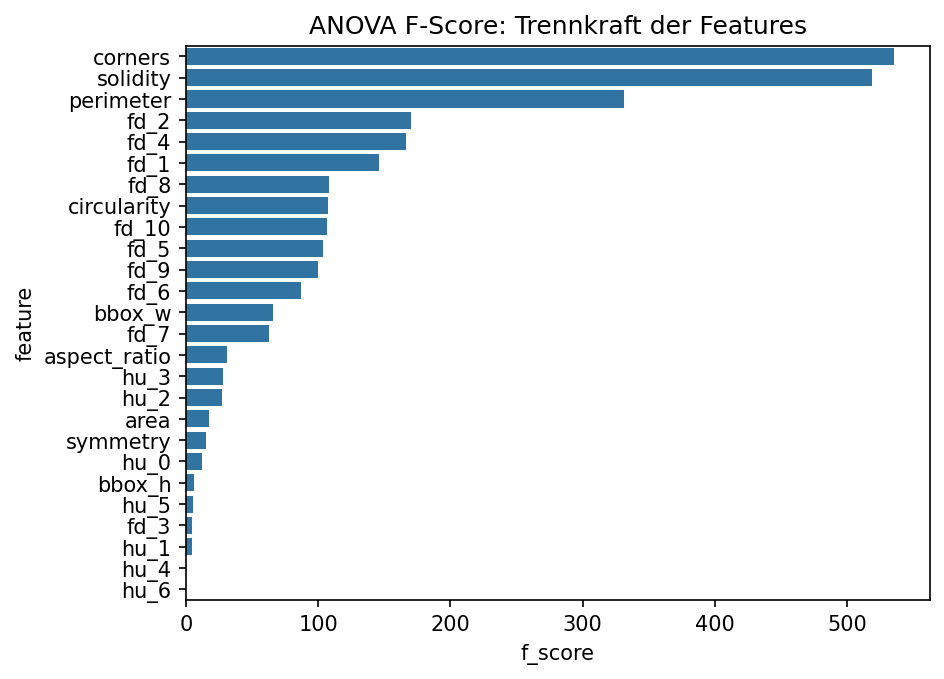

In [113]:
from sklearn.feature_selection import f_classif

X = df.drop(columns=["label"])
y = df["label"]

f_scores, p_values = f_classif(X, y)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print(importance_df)

# Als Plot
sns.barplot(data=importance_df, x="f_score", y="feature")
plt.title("ANOVA F-Score: Trennkraft der Features")
plt.show()

In [114]:
selected_features = ["corners", "fd_4","perimeter",  "circularity",    "hu_4",  "fd_2","bbox_w",  "fd_3",  "fd_5",  "hu_1","solidity","fd_7",  "fd_6", "hu_0", "hu_2", "hu_3","hu_5","hu_6", "fd_1", "area"]  # 
#  

X = df[selected_features]  # use the selected feature columns
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


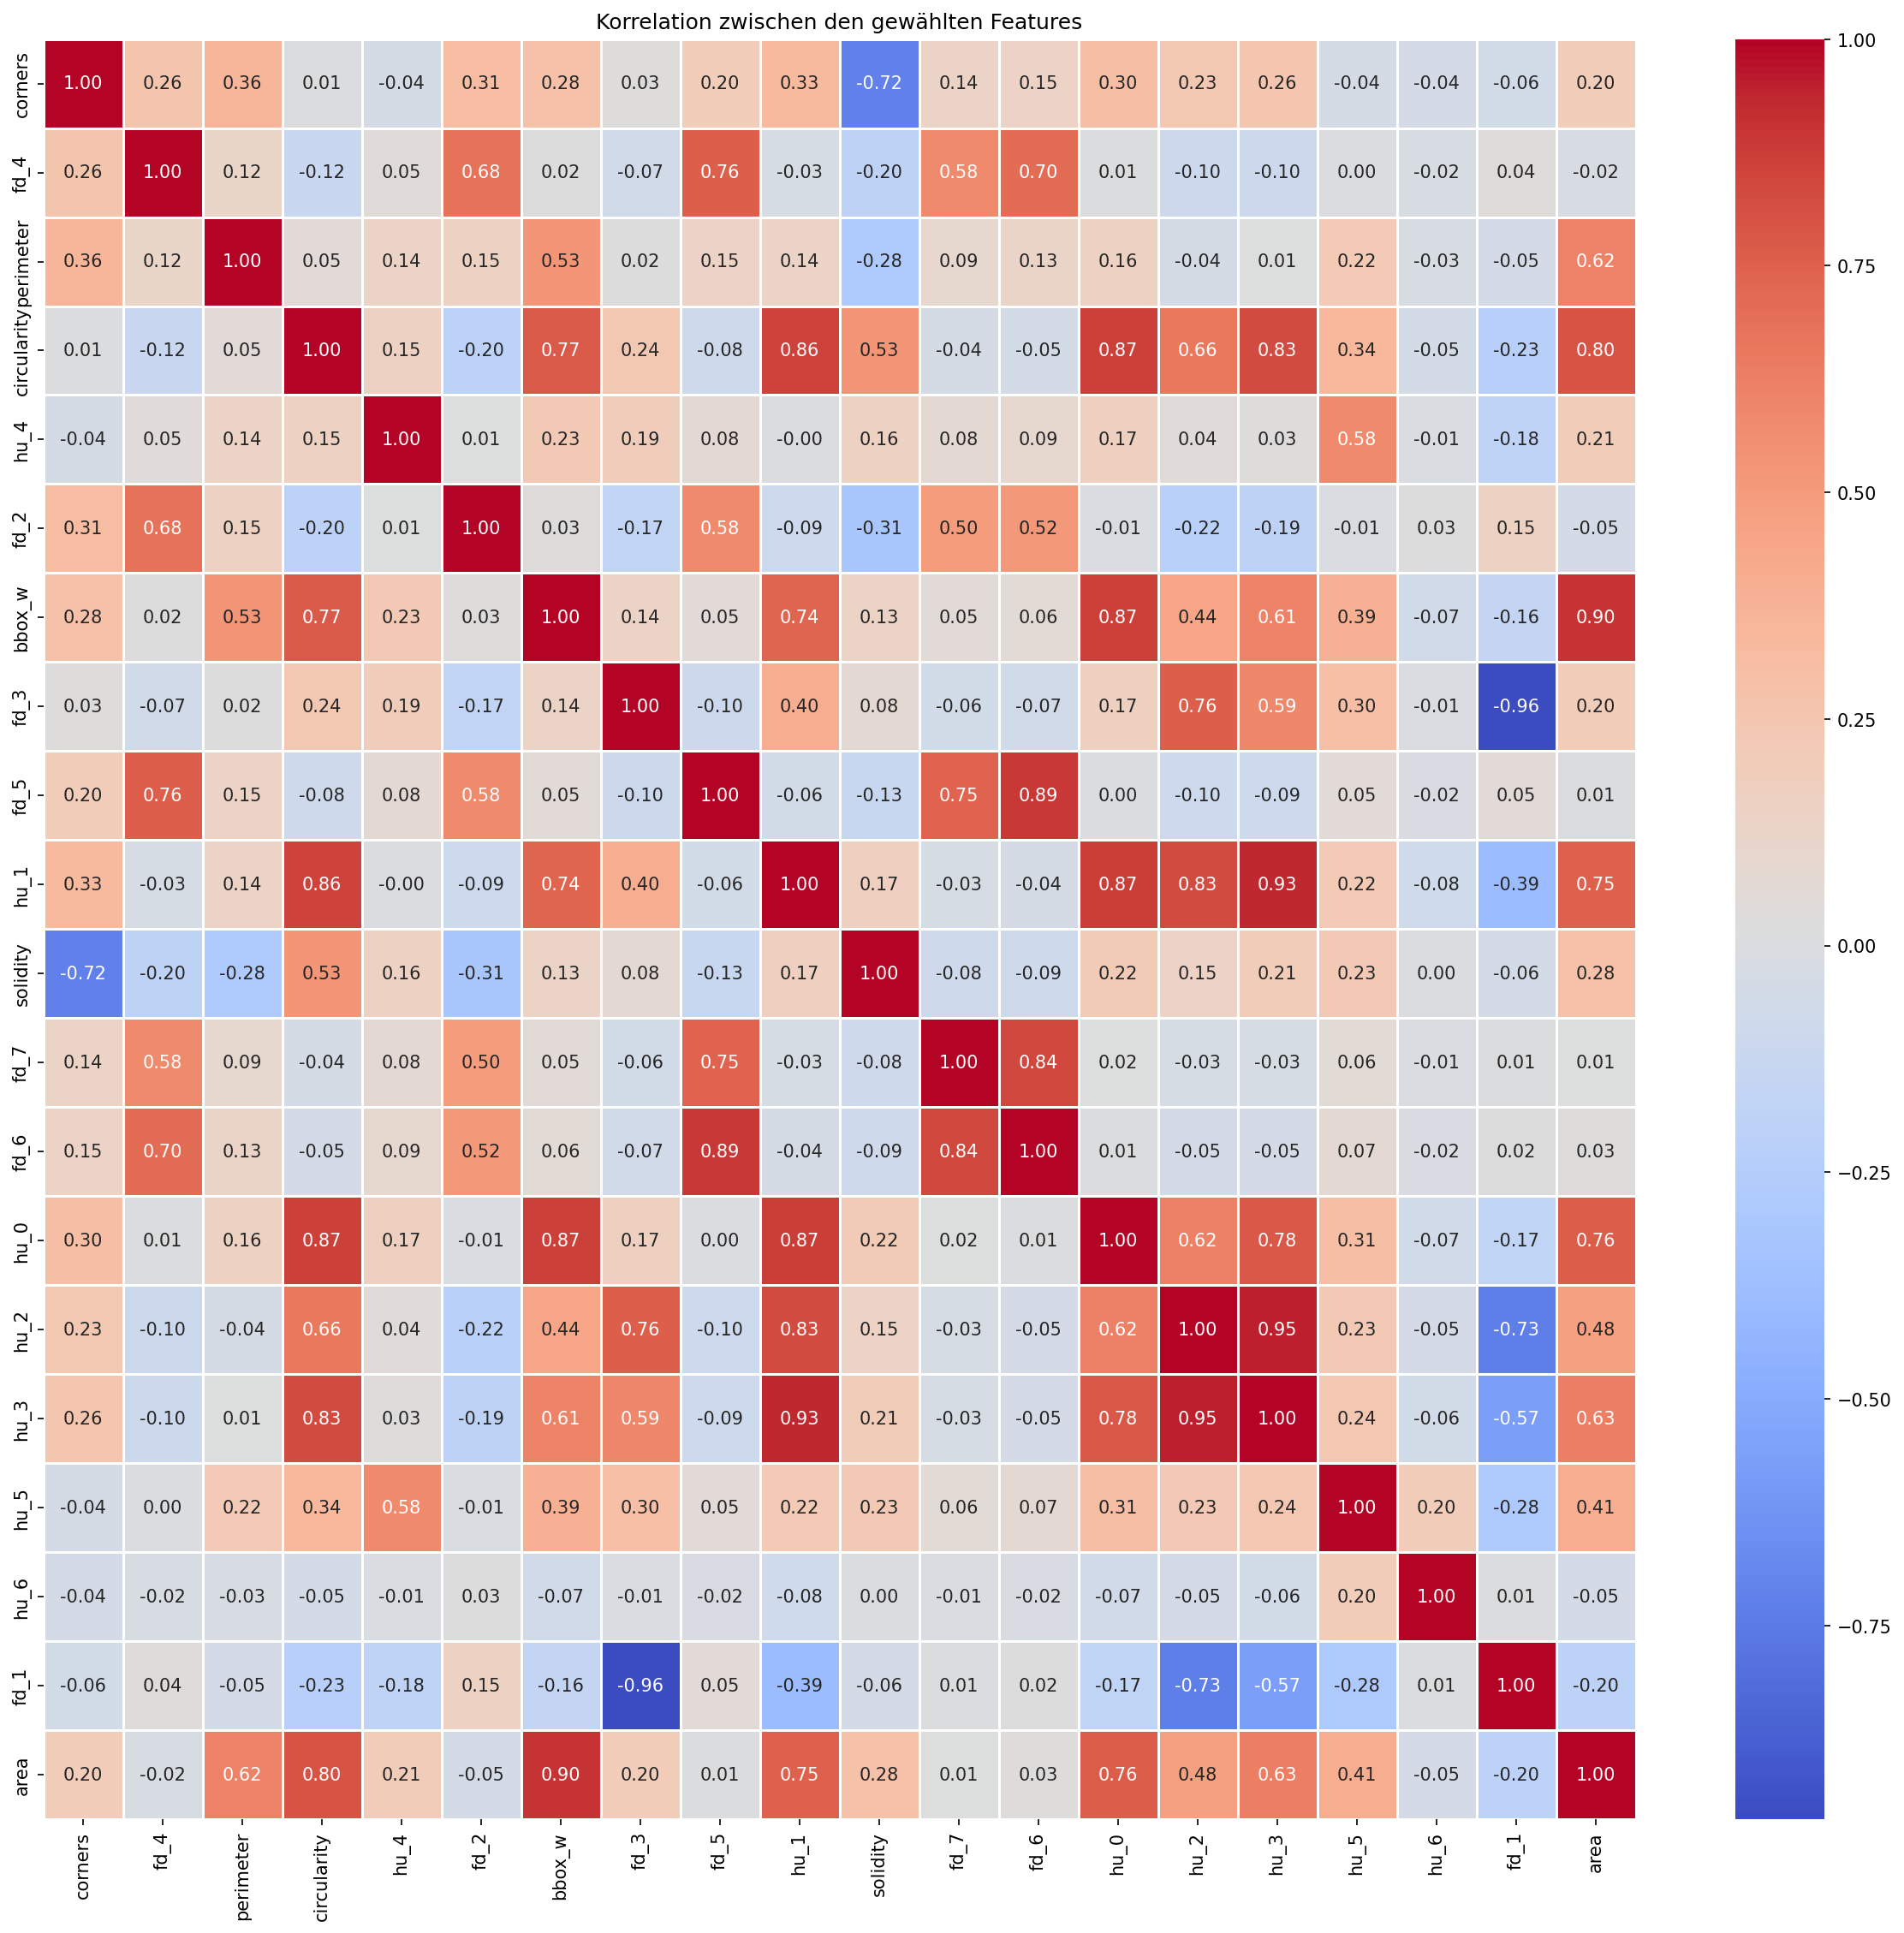

In [115]:
corr = df[selected_features].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korrelation zwischen den gewählten Features")
plt.show()

In [116]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=31
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         cat       0.60      0.77      0.67      2060
    rejected       0.82      0.73      0.77      1650
     unicorn       0.71      0.56      0.62      2010

    accuracy                           0.69      5720
   macro avg       0.71      0.69      0.69      5720
weighted avg       0.70      0.69      0.69      5720



In [118]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
print(f"CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

CV F1: 0.692 ± 0.008


In [119]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10, 15],
    "min_samples_leaf": [1, 2, 3, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Beste Parameter:", grid.best_params_)
print("Bester Score:", grid.best_score_)

Beste Parameter: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 300}
Bester Score: 0.7592485649892123


In [120]:
from sklearn.feature_selection import SelectFromModel

# Bestes Modell aus GridSearch
best_model = grid.best_estimator_

# Selector trainieren
selector = SelectFromModel(best_model, threshold="median", prefit=True)

# Features filtern
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

# Welche Features wurden gewählt?
selected_mask = selector.get_support()
selected_names = list(X.columns[selected_mask])
print(f"Features vorher: {X_train.shape[1]}")
print(f"Features nachher: {X_train_sel.shape[1]}")
print(f"Gewählte Features: {selected_names}")

Features vorher: 20
Features nachher: 10
Gewählte Features: ['perimeter', 'circularity', 'hu_1', 'solidity', 'hu_0', 'hu_2', 'hu_3', 'hu_5', 'hu_6', 'area']


/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [121]:
# Neues Modell mit den selektierten Features
model_final = RandomForestClassifier(
    **grid.best_params_,
    class_weight="balanced",
    random_state=42
)

model_final.fit(X_train_sel, y_train)
pred_final = model_final.predict(X_test_sel)
print(classification_report(y_test, pred_final))

              precision    recall  f1-score   support

         cat       0.71      0.64      0.68      2060
    rejected       0.96      0.75      0.84      1650
     unicorn       0.63      0.80      0.70      2010

    accuracy                           0.73      5720
   macro avg       0.77      0.73      0.74      5720
weighted avg       0.75      0.73      0.73      5720



In [122]:
joblib.dump({
    "model": model_final,
    "selector": selector,
    "selected_features": selected_names,
    "all_features": list(X.columns)
}, "random_forest_model.pkl")
print("Model saved.")

Model saved.


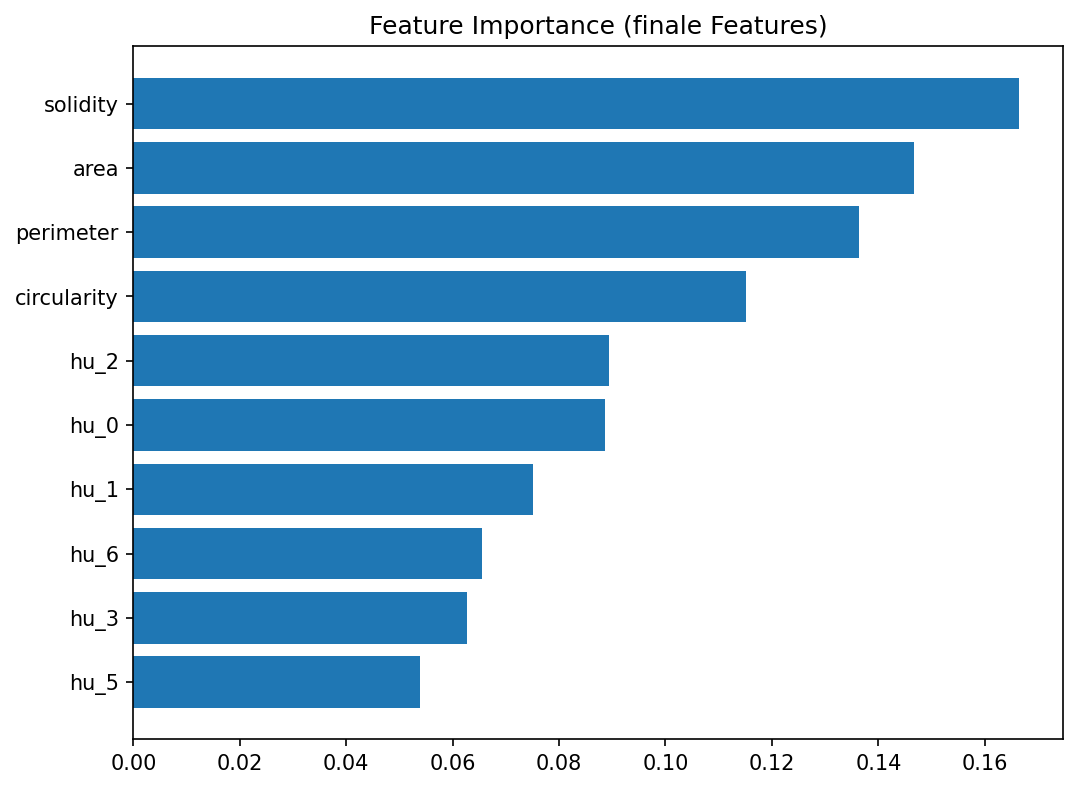

In [123]:
importances = model_final.feature_importances_  # ← model_final!
names = selected_names

idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(np.array(names)[idx], importances[idx])
plt.title("Feature Importance (finale Features)")
plt.show()